# Xử lý dữ liệu chuỗi thời gian — NASA POWER Hà Nội (2001–2025)
**Bản nguồn: Weather-Prediction-ML(2).zip • Quy trình: raw → audit → quyết định xử lý → cleaned có truy vết.**

Notebook dành cho dự án dự báo nhiệt độ và mưa trước 1 giờ. Mỗi dòng là một giờ tại điểm lưới NASA POWER, không phải quan trắc trực tiếp từ trạm Hà Nội. Dữ liệu gốc UTC; phân tích chu kỳ ngày dùng GMT+7.

Đặt file này trong `Weather-Prediction-ML/notebooks/`, chọn kernel Python và **Run All**. Cần `pandas`, `numpy`, `matplotlib` (có trong requirements của dự án); notebook dùng IPython để hiển thị. Nếu thiếu thư viện, chạy `%pip install pandas numpy matplotlib` ở một cell riêng rồi khởi động lại kernel.

Notebook chạy trên **raw và cleaned**, không đọc processed, không chia train/test và không huấn luyện. Ngưỡng thống kê trên toàn kỳ chỉ dùng EDA: không mang nguyên chúng sang đánh giá dự báo. Các output được ghi vào thư mục riêng, không ghi đè dữ liệu hoặc code dự án.


## 1. Cấu hình và tìm đúng dự án
Tên file được cố định theo bản zip mới, tránh vô tình dùng bộ 2023–2024. Chạy từ thư mục gốc hoặc `notebooks/` đều được. GMT+7 cố định giúp chạy trên Windows mà không phụ thuộc cơ sở dữ liệu timezone.

`FILL_SHORT_GAPS=False`: mặc định giữ thiếu và báo cáo. Bật tùy chọn chỉ điền các khoảng thiếu **toàn bộ dài ≤2 giờ**, bằng giá trị quá khứ của T2M/RH2M/PS. Không tự điền mưa, bức xạ, tốc độ/hướng gió; không nội suy bằng tương lai.


In [1]:
from pathlib import Path
from datetime import timezone, timedelta, datetime
import json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = None  # Nếu cần: Path(r"C:\Users\ameli\OneDrive\Documents\Weather-Prediction-ML")
if PROJECT_ROOT is None:
    roots = [Path.cwd(), *Path.cwd().parents]
    PROJECT_ROOT = next((p for p in roots if (p / 'data/raw/nasa_power').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Đặt notebook trong thư mục notebooks của dự án hoặc điền PROJECT_ROOT.')
PROJECT_ROOT = Path(PROJECT_ROOT).resolve()
STEM = 'hanoi_hourly_20010101_20251231'
RAW_PATH = PROJECT_ROOT / 'data/raw/nasa_power' / (STEM + '.csv')
CLEAN_PATH = PROJECT_ROOT / 'data/cleaned/nasa_power' / (STEM + '_clean.csv')
RAW_META_PATH = RAW_PATH.with_suffix('.metadata.json')
CLEAN_META_PATH = CLEAN_PATH.with_suffix('.metadata.json')
OUT = PROJECT_ROOT / 'outputs/timeseries_quality_v2'
OUT.mkdir(parents=True, exist_ok=True)
TZ = timezone(timedelta(hours=7))
VARS = ['T2M','PRECTOTCORR','RH2M','PS','WS2M','WD2M','ALLSKY_SFC_SW_DWN']
FILL_SHORT_GAPS = False
MAX_FILL_HOURS = 2
RAIN_THRESHOLD = 0.1  # Đồng nhất với features.py: mưa nếu > 0.1 mm/giờ
plt.rcParams.update({'figure.figsize': (13,4), 'axes.grid': True, 'grid.alpha': .2})
def sha(path): return hashlib.sha256(path.read_bytes()).hexdigest()
raw_hash = sha(RAW_PATH)
raw_meta = json.loads(RAW_META_PATH.read_text(encoding='utf-8'))
raw = pd.read_csv(RAW_PATH, encoding='utf-8-sig')
text_raw = pd.read_csv(RAW_PATH, encoding='utf-8-sig', dtype='string', keep_default_na=False)
assert set(['timestamp','city','latitude','longitude', *VARS]) <= set(raw.columns)
assert raw_meta['time_standard'] == 'UTC', 'Cần xác minh múi giờ nguồn trước khi xử lý.'
display(pd.DataFrame(raw_meta['parameters']).T)
print('Nguồn:', RAW_PATH.name, '| số dòng:', len(raw), '| SHA256:', raw_hash)


Nguồn: hanoi_hourly_20010101_20251231.csv | số dòng: 219144 | SHA256: 5af4c1a2d36dce8babac95e695d126b07605d61cd3e178b447e1496c0ce36ad8


,units,longname
T2M,C,Temperature at 2 Meters
PRECTOTCORR,mm/hour,Precipitation Corrected
RH2M,%,Relative Humidity at 2 Meters
PS,kPa,Surface Pressure
WS2M,m/s,Wind Speed at 2 Meters
WD2M,Degrees,Wind Direction at 2 Meters
ALLSKY_SFC_SW_DWN,Wh/m^2,All Sky Surface Shortwave Downward Irradiance


## 2. Audit cấu trúc, unique, duplicate và thiếu ẩn
`n_unique` giúp phát hiện cột hằng và định danh; không dùng số unique để kết luận biến khí tượng là tốt/xấu. Số 0 của mưa/bức xạ là giá trị hợp lệ. Kiểm tra cả chuỗi trống, lỗi đọc số, ±Infinity và fill value trong metadata, không chỉ `isna()` sau đọc CSV.


In [2]:
def audit(df):
    return pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum(),
                         'missing_pct':df.isna().mean()*100, 'unique':df.nunique(dropna=True)})
display(audit(raw))
print('Dòng trùng toàn bộ:', raw.duplicated().sum())
print('City:', text_raw.city.value_counts(dropna=False).to_dict())
fill_values = {-999.0}
fill_values.update(float(s['fill_value']) for s in raw_meta.get('sources', []) if s.get('fill_value') is not None)
numeric = raw[VARS].apply(pd.to_numeric, errors='coerce')
hidden = pd.DataFrame({
    'blank': text_raw[VARS].apply(lambda s:s.str.strip().eq('').sum()),
    'unparseable': (numeric.isna() & text_raw[VARS].apply(lambda s:s.str.strip().ne(''))).sum(),
    'infinity': np.isinf(numeric).sum(),
    'fill_value': numeric.isin(fill_values).sum()})
display(hidden)
display(numeric.describe(percentiles=[.01,.25,.5,.75,.99]).T)


Dòng trùng toàn bộ: 0
City: {'Hanoi': 219144}


,dtype,missing,missing_pct,unique
timestamp,object,0,0.0,219144
city,object,0,0.0,1
latitude,float64,0,0.0,1
longitude,float64,0,0.0,1
T2M,float64,0,0.0,3691
PRECTOTCORR,float64,0,0.0,746
RH2M,float64,0,0.0,6825
PS,float64,0,0.0,504
WS2M,float64,0,0.0,774
WD2M,float64,0,0.0,3595


,blank,unparseable,infinity,fill_value
T2M,0,0,0,0
PRECTOTCORR,0,0,0,0
RH2M,0,0,0,0
PS,0,0,0,0
WS2M,0,0,0,0
WD2M,0,0,0,0
ALLSKY_SFC_SW_DWN,0,0,0,0


,count,mean,std,min,1%,25%,50%,75%,99%,max
T2M,219144.0,23.326143,6.217643,1.53,7.7843,19.12,24.65,27.66,34.7000,41.92
PRECTOTCORR,219144.0,0.190689,0.553449,0.00,0.0000,0.00,0.01,0.12,2.5800,30.90
RH2M,219144.0,82.382949,14.558176,17.04,42.2100,71.88,86.52,94.77,100.0000,100.00
PS,219144.0,100.099146,0.725261,97.27,98.7900,99.51,100.05,100.65,101.7200,103.05
WS2M,219144.0,1.738663,1.034150,0.00,0.2700,0.95,1.49,2.32,4.8400,11.64
WD2M,219144.0,135.306869,86.937896,0.00,3.7000,64.60,135.60,166.50,355.5000,359.90
ALLSKY_SFC_SW_DWN,219144.0,155.819978,228.230371,0.00,0.0000,0.00,5.50,262.35,833.3414,1020.80


## 3. Audit trục thời gian theo phạm vi metadata
**Không có missing trong các ô không chứng minh đủ giờ.** CSV có thể mất nguyên dòng; phải đối chiếu tập thời điểm kỳ vọng. Dữ liệu UTC 2001-01-01 00:00 → 2025-12-31 23:00 tương ứng giờ Việt Nam 2001-01-01 07:00 → 2026-01-01 06:00. Bảy giờ đầu năm 2026 là cùng dữ liệu nguồn, không phải thêm một năm.

Timestamp không có offset, lỗi parse hoặc lệch phút được báo và chặn; không tự gán timezone khi chưa có bằng chứng.


In [3]:
explicit_tz = text_raw.timestamp.str.contains(r'(Z|[+-]\d{2}:?\d{2})$', regex=True)
ts = pd.to_datetime(raw.timestamp, utc=True, errors='coerce')
bad_time = ts.isna() | ~explicit_tz | ts.ne(ts.dt.floor('h'))
if bad_time.any():
    display(raw.loc[bad_time].head(20))
    raise ValueError('Timestamp không hợp lệ; sửa nguồn có bằng chứng trước khi tiếp tục.')
start = pd.Timestamp(raw_meta['start'], tz='UTC')
end = pd.Timestamp(raw_meta['end'], tz='UTC') + pd.Timedelta(hours=23)
expected = pd.date_range(start, end, freq='h').tz_convert(TZ)
local_ts = ts.dt.tz_convert(TZ)
observed = pd.DatetimeIndex(local_ts.unique()).sort_values()
missing_hours = expected.difference(observed)
extra_hours = observed.difference(expected)
time_audit = {'input_rows':len(raw), 'expected_hours':len(expected),
              'unique_hours':len(observed), 'duplicate_timestamps':int(ts.duplicated().sum()),
              'missing_hours':len(missing_hours), 'outside_metadata':len(extra_hours),
              'sorted_in_source':bool(ts.is_monotonic_increasing),
              'local_start':str(expected[0]), 'local_end':str(expected[-1])}
display(pd.Series(time_audit))
assert len(extra_hours)==0, 'Có giờ ngoài phạm vi metadata.'
assert raw.city.str.strip().eq('Hanoi').all()
assert np.isclose(raw.latitude, raw_meta['latitude'], atol=1e-6, rtol=0).all()
assert np.isclose(raw.longitude, raw_meta['longitude'], atol=1e-6, rtol=0).all()


cell_6:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.


input_rows                                 219144
expected_hours                             219144
unique_hours                               219144
duplicate_timestamps                            0
missing_hours                                   0
outside_metadata                                0
sorted_in_source                             True
local_start             2001-01-01 07:00:00+07:00
local_end               2026-01-01 06:00:00+07:00
dtype: object

## 4. Làm sạch xác định được và ghi nhật ký từng ô
Chỉ sửa lỗi có quy tắc rõ: thiếu ẩn/ngoài miền vật lý → NaN; WD2M=360 → 0; gộp dòng trùng giống nhau và lưu mọi số dòng nguồn. Trùng cùng giờ nhưng khác dữ liệu phải giải quyết từ nguồn, không lấy trung bình.

Miền vật lý dưới đây là kiểm tra tối thiểu; nhiệt độ 40°C, mưa lớn hoặc áp suất thấp có thể là thời tiết thật. Không đặt giới hạn tùy tiện để cắt các cực trị đó.


In [4]:
work = raw.copy()
work['source_row'] = np.arange(1,len(work)+1)
work['timestamp'] = local_ts
change_log = []
def log_cells(mask, column, after, reason):
    for i in work.index[mask]:
        change_log.append({'source_row':int(work.at[i,'source_row']),
                           'timestamp':str(work.at[i,'timestamp']), 'column':column,
                           'before':str(raw.at[i,column]), 'after':str(after), 'reason':reason})
invalid_counts = {}
for c in VARS:
    x = numeric[c]
    bad = x.isna() | ~np.isfinite(x) | x.isin(fill_values)
    if c=='T2M': bad |= x < -273.15
    if c=='RH2M': bad |= ~x.between(0,100)
    if c=='PS': bad |= x<=0
    if c=='WD2M': bad |= ~x.between(0,360)
    if c in ['PRECTOTCORR','WS2M','ALLSKY_SFC_SW_DWN']: bad |= x<0
    invalid_counts[c] = int(bad.sum())
    log_cells(bad,c,np.nan,'missing_or_invalid_physical_domain')
    work[c] = x.mask(bad)
mask360 = work.WD2M.eq(360)
log_cells(mask360,'WD2M',0,'circular_360_to_0')
work.loc[mask360,'WD2M'] = 0
compare_cols = ['city','latitude','longitude', *VARS]
duplicate_mask = work.timestamp.duplicated(keep=False)
if duplicate_mask.any():
    conflicts = work.loc[duplicate_mask].groupby('timestamp')[compare_cols].nunique(dropna=False).gt(1).any(axis=1)
    assert not conflicts.any(), 'Trùng giờ xung đột: cần đối chiếu response JSON.'
lineage = work.groupby('timestamp').source_row.agg(lambda x:'|'.join(map(str,x)))
base = work.drop_duplicates('timestamp').set_index('timestamp').sort_index()
clean = base.reindex(expected).copy()
clean.index.name = 'timestamp'
clean['source_row_numbers'] = lineage.reindex(expected).fillna('none')
clean['is_inserted_hour'] = (~expected.isin(base.index)).astype(int)
for c,v in {'city':'Hanoi','latitude':raw_meta['latitude'],'longitude':raw_meta['longitude']}.items(): clean[c] = v
clean = clean.drop(columns='source_row')
missing_before_fill = clean[VARS].isna()
display(pd.Series(invalid_counts, name='invalid_cells'))


T2M                  0
PRECTOTCORR          0
RH2M                 0
PS                   0
WS2M                 0
WD2M                 0
ALLSKY_SFC_SW_DWN    0
Name: invalid_cells, dtype: int64

## 5. Khoảng thiếu và chính sách điền có giới hạn
Báo cáo **theo đoạn**: bắt đầu, kết thúc, độ dài. Bảng này phân biệt mất giờ với thiếu riêng một biến. Mặc định không điền; nếu bật điền ngắn, cờ provenance cho biết đúng biến nào đã điền. Đầu chuỗi thiếu sẽ giữ NaN do không có giá trị quá khứ.

Mưa thiếu không đồng nghĩa không mưa. Hướng gió 359° và 1° gần nhau; không nội suy tuyến tính thành 180°.


In [5]:
def runs(mask):
    mask = mask.fillna(False).astype(bool)
    groups = mask.ne(mask.shift(fill_value=False)).cumsum()
    records=[]
    for _, s in mask[mask].groupby(groups[mask]):
        records.append({'start':s.index[0], 'end':s.index[-1], 'hours':len(s)})
    return pd.DataFrame(records, columns=['start','end','hours'])
gap_tables=[]
for c in VARS:
    table = runs(clean[c].isna()); table['variable']=c; gap_tables.append(table)
gaps = pd.concat(gap_tables, ignore_index=True)
display(gaps.sort_values('hours',ascending=False).head(20))
filled = pd.DataFrame(False, index=clean.index, columns=VARS)
if FILL_SHORT_GAPS:
    for c in ['T2M','RH2M','PS']:
        missing = clean[c].isna()
        groups = missing.ne(missing.shift(fill_value=False)).cumsum()
        length = missing.groupby(groups).transform('sum')
        candidate = clean[c].ffill(limit=MAX_FILL_HOURS)
        eligible = missing & length.le(MAX_FILL_HOURS) & candidate.notna()
        for t in clean.index[eligible]:
            change_log.append({'source_row':clean.at[t,'source_row_numbers'], 'timestamp':str(t),
                               'column':c,'before':'nan','after':str(candidate.at[t]),
                               'reason':'causal_ffill_complete_gap_le_2h'})
        clean.loc[eligible,c] = candidate.loc[eligible]
        filled.loc[eligible,c] = True
clean['is_imputed'] = filled.any(axis=1).astype(int)
clean['imputed_columns'] = filled.apply(lambda row:'|'.join(row.index[row]) or 'none',axis=1)
print('Giờ bổ sung:',clean.is_inserted_hour.sum(), '| Dòng điền:',clean.is_imputed.sum())
display(audit(clean[VARS]))


Giờ bổ sung: 0 | Dòng điền: 0


,start,end,hours,variable


,dtype,missing,missing_pct,unique
T2M,float64,0,0.0,3691
PRECTOTCORR,float64,0,0.0,746
RH2M,float64,0,0.0,6825
PS,float64,0,0.0,504
WS2M,float64,0,0.0,774
WD2M,float64,0,0.0,3595
ALLSKY_SFC_SW_DWN,float64,0,0.0,31922


## 6. Đối chiếu raw–cleaned hiện có trong zip
So sánh theo **cùng thời điểm UTC**, không so chuỗi timestamp nguyên văn. Kiểm tra hash và provenance; đếm thay đổi từng biến. Dữ liệu cleaned hiện có đã nội suy hồi cứu nếu có thiếu; notebook dùng chính sách riêng ở trên và xuất file riêng. Không gọi lại cleaning.py vì hàm đó điền mọi khoảng thiếu và ghi vào data/cleaned.


In [6]:
existing_comparison = pd.DataFrame()
if CLEAN_PATH.exists():
    old = pd.read_csv(CLEAN_PATH)
    old_meta = json.loads(CLEAN_META_PATH.read_text(encoding='utf-8'))
    assert old_meta['dataset_id'] == 'sha256:' + sha(CLEAN_PATH)
    assert old_meta['source_sha256'] == raw_hash
    old.index = pd.to_datetime(old.timestamp, utc=True).dt.tz_convert(TZ)
    assert old.index.is_unique
    common = clean.index.intersection(old.index)
    a,b = clean.loc[common,VARS],old.loc[common,VARS].apply(pd.to_numeric,errors='coerce')
    differences = pd.DataFrame(~np.isclose(a,b,rtol=0,atol=1e-9,equal_nan=True),index=common,columns=VARS)
    existing_comparison = pd.DataFrame({'changed_cells_vs_notebook':differences.sum(),
                                       'existing_missing':b.isna().sum(),'notebook_missing':a.isna().sum()})
    display(existing_comparison)
    print('Chỉ có trong notebook:',len(clean.index.difference(old.index)),
          '| chỉ có trong cleaned cũ:',len(old.index.difference(clean.index)))
    display(old[['is_imputed','is_inserted_hour']].sum())
else:
    print('Không có cleaned hiện hữu; tiếp tục kiểm tra bản sao raw.')


Chỉ có trong notebook: 0 | chỉ có trong cleaned cũ: 0


,changed_cells_vs_notebook,existing_missing,notebook_missing
T2M,0,0,0
PRECTOTCORR,0,0,0
RH2M,0,0,0
PS,0,0,0
WS2M,0,0,0
WD2M,0,0,0
ALLSKY_SFC_SW_DWN,0,0,0


is_imputed          0
is_inserted_hour    0
dtype: int64

## 7. Khám phá chu kỳ và thay đổi phân bố qua 25 năm
Tổng hợp tháng/năm thay cho xem hơn 1.300 tuần bằng mắt. Nhiệt độ dùng mean và dải min–max; mưa dùng tổng có kiểm tra số giờ quan trắc. Tháng/năm đầu cuối theo giờ địa phương có thể không đầy đủ: không so tổng mưa của một kỳ thiếu với kỳ đủ.

Heatmap tháng × giờ giải thích bức xạ ban ngày và chu kỳ mùa. Đây là EDA, chưa phải kết luận biến đổi khí hậu hay lỗi thiết bị.


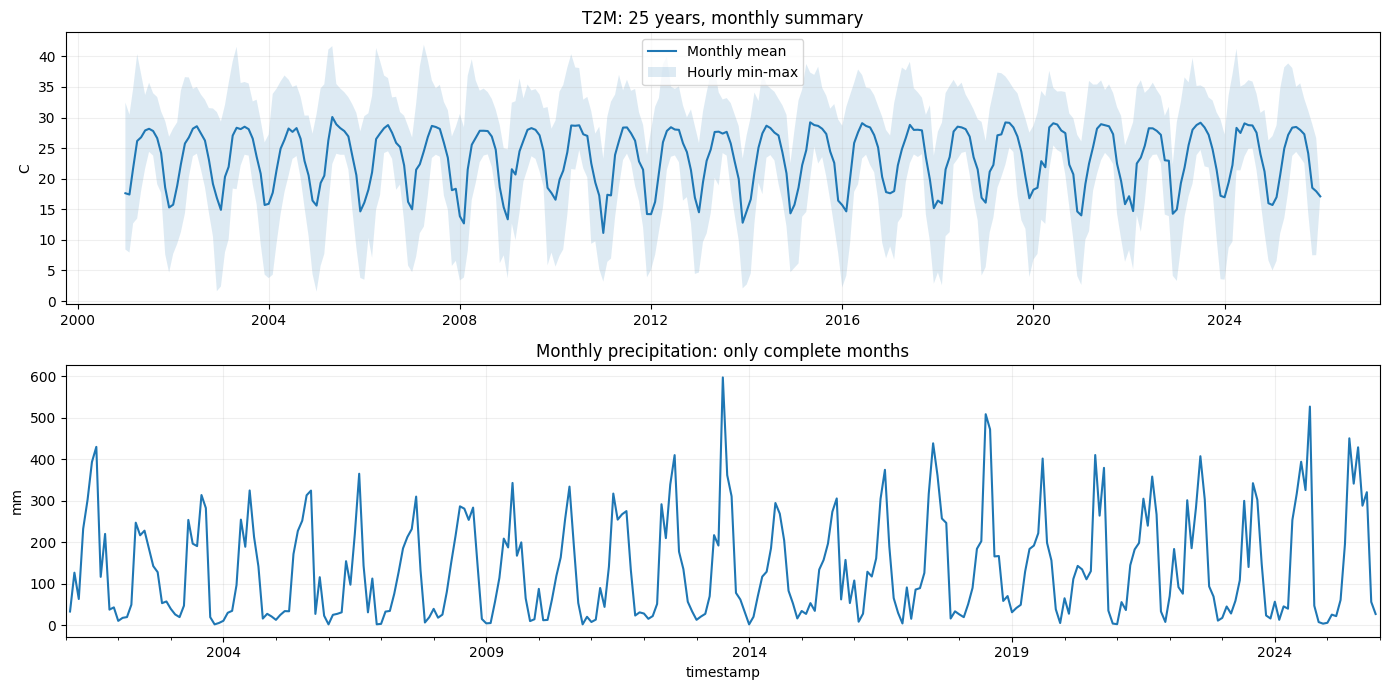

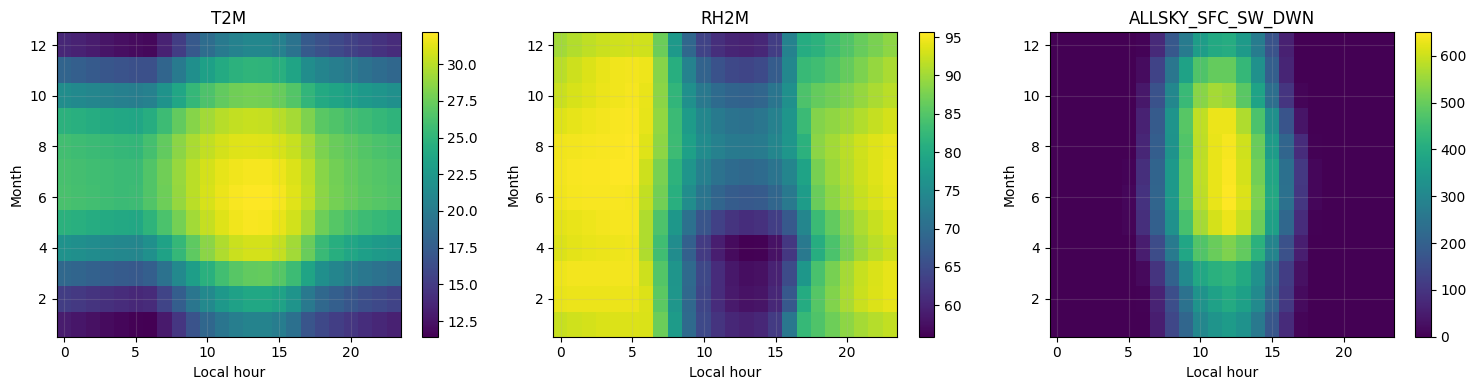

T2M                      ... ALLSKY_SFC_SW_DWN                    
             mean    min    max count  ...              mean  min      max count
timestamp                              ...                                      
2001       23.219   4.64  40.38  8753  ...           154.920  0.0   976.12  8753
2002       23.275   1.60  36.61  8760  ...           152.605  0.0   975.88  8760
2003       23.666   2.38  41.58  8760  ...           170.341  0.0   993.00  8760
2004       23.079   3.74  36.88  8784  ...           161.053  0.0   996.67  8784
2005       23.564   1.53  41.69  8760  ...           158.479  0.0   992.88  8760
2006       23.625   3.48  41.37  8760  ...           157.496  0.0  1020.80  8760
2007       23.440   4.73  41.92  8760  ...           160.289  0.0  1008.17  8760
2008       22.474   3.36  39.53  8784  ...           151.084  0.0   948.90  8784
2009       23.202   3.72  36.38  8760  ...           161.571  0.0   957.15  8760
2010       23.481   5.23  40.36  8760  ...           157.571  0.0   980.65  8760
2011       22.071   3.17  36.99  8760  ...           146.591  0.0   958.03  8760
2012       23.184   4.43  39.94  8784  ...           149.741  0.0  1011.35  8784
2013       22.790   2.07  37.95  8760  ...           152.625  0.0   997.78  8760
2014       23.022   2.70  37.32  8760  ...           153.002  0.0   977.00  8760
2015       23.919   5.43  38.77  8760  ...           160.615  0.0  1011.70  8760
2016       23.386   2.22  37.86  8784  ...           161.867  0.0   984.58  8784
2017       23.404   2.83  39.12  8760  ...           146.504  0.0   975.80  8760
2018       23.289   2.57  36.17  8760  ...           153.008  0.0   976.12  8760
2019       24.087   3.92  37.35  8760  ...           156.395  0.0   961.75  8760
2020       23.412   4.10  37.64  8784  ...           153.133  0.0  1011.83  8784
2021       23.381   2.63  36.08  8760  ...           159.031  0.0   973.53  8760
2022       22.947   4.12  36.10  8760  ...           152.407  0.0  1015.92  8760
2023       23.899   3.29  39.74  8760  ...           162.486  0.0   988.47  8760
2024       24.135   3.50  41.27  8784  ...           151.041  0.0   987.80  8784
2025       23.208   5.00  38.85  8760  ...           151.788  0.0   990.08  8760
2026       17.114  16.89  17.42     7  ...             0.297  0.0     2.08     7

[26 rows x 28 columns]

In [7]:
monthly = clean[VARS].resample('MS').mean()
fig,axes = plt.subplots(2,1,figsize=(14,7))
axes[0].plot(monthly.index,monthly.T2M,label='Monthly mean')
tmin=clean.T2M.resample('MS').min(); tmax=clean.T2M.resample('MS').max()
axes[0].fill_between(monthly.index,tmin,tmax,alpha=.15,label='Hourly min-max')
axes[0].set_title('T2M: 25 years, monthly summary'); axes[0].set_ylabel('C'); axes[0].legend()
rain_sum = clean.PRECTOTCORR.resample('MS').sum(min_count=1)
rain_count = clean.PRECTOTCORR.resample('MS').count()
full_month_hours = rain_sum.index.days_in_month*24
rain_sum.where(rain_count.eq(full_month_hours)).plot(ax=axes[1])
axes[1].set_title('Monthly precipitation: only complete months'); axes[1].set_ylabel('mm')
plt.tight_layout(); plt.show()
fig,axes = plt.subplots(1,3,figsize=(15,4))
for ax,c in zip(axes,['T2M','RH2M','ALLSKY_SFC_SW_DWN']):
    pivot=clean.groupby([clean.index.month,clean.index.hour])[c].mean().unstack()
    im=ax.imshow(pivot,aspect='auto',origin='lower',extent=[-.5,23.5,.5,12.5]); fig.colorbar(im,ax=ax)
    ax.set_title(c); ax.set_xlabel('Local hour'); ax.set_ylabel('Month')
plt.tight_layout();plt.show()
yearly = clean.groupby(clean.index.year)[VARS].agg(['mean','min','max','count'])
display(yearly.round(3))


### 7.1. Nhìn rõ mùa mưa–khô bằng ba biểu đồ bổ sung
Biểu đồ đường 25 năm ở trên giúp nhìn biến động dài hạn. Ba biểu đồ sau trả lời cụ thể: **tháng nào thường mưa nhiều, mức độ thay đổi giữa các năm và năm nào khác biệt?**

Trước tiên tính **tổng mưa từng tháng của từng năm**, sau đó mới lấy trung bình theo tháng 1–12. Không lấy trung bình mọi giá trị mưa theo giờ rồi gọi đó là tổng mưa tháng.

Chỉ dùng tháng có đủ số giờ lịch địa phương và đủ giá trị mưa quan trắc, không dùng giá trị mưa được điền. Tháng 1/2001 thiếu 7 giờ đầu phạm vi địa phương; tháng 1/2026 chỉ có 7 giờ. Hai tháng này bị loại khỏi so sánh, không có nghĩa chuỗi UTC mất giờ. Các tháng khác thiếu dữ liệu cũng bị loại và báo ở bảng dưới. Số năm dùng cho mỗi tháng có thể khác nhau.

In [8]:
# Mưa quan trắc: loại ô được điền và giờ bổ sung khỏi phép tổng hợp này.
rain_observed = clean['PRECTOTCORR'].copy()
rain_imputed = clean['imputed_columns'].fillna('none').str.split('|').apply(
    lambda names: 'PRECTOTCORR' in names)
rain_observed = rain_observed.mask(rain_imputed | clean['is_inserted_hour'].eq(1))
rain_monthly = pd.DataFrame({
    'rain_total_mm': rain_observed.resample('MS').sum(min_count=1),
    'observed_hours': rain_observed.resample('MS').count()
})
rain_monthly['expected_hours'] = rain_monthly.index.days_in_month * 24
rain_monthly['coverage_pct'] = 100 * rain_monthly.observed_hours / rain_monthly.expected_hours
rain_monthly['is_complete'] = rain_monthly.observed_hours.eq(rain_monthly.expected_hours)
rain_monthly['year'] = rain_monthly.index.year
rain_monthly['month'] = rain_monthly.index.month
rain_monthly.index.name = 'month_start'
rain_complete = rain_monthly.loc[rain_monthly.is_complete].copy()
assert not rain_complete.empty, 'Không có tháng đủ dữ liệu mưa để so sánh.'
print('Các tháng không đủ dữ liệu — không đưa vào ba biểu đồ:')
display(rain_monthly.loc[~rain_monthly.is_complete])
month_order = pd.Index(range(1,13), name='month')
rain_climatology = rain_complete.groupby('month').rain_total_mm.agg(
    mean_mm='mean', median_mm='median', min_mm='min', max_mm='max', n_years='count'
).reindex(month_order)
display(rain_climatology.round(2))

Các tháng không đủ dữ liệu — không đưa vào ba biểu đồ:


,rain_total_mm,observed_hours,expected_hours,coverage_pct,is_complete,year,month
month_start,,,,,,,
2001-01-01 00:00:00+07:00,20.12,737,744,99.05914,False,2001,1
2026-01-01 00:00:00+07:00,0.07,7,744,0.94086,False,2026,1


,mean_mm,median_mm,min_mm,max_mm,n_years
month,,,,,
1,31.95,21.70,1.91,107.68,24
2,30.19,24.75,5.08,183.65,25
3,48.02,34.60,12.70,126.55,25
4,77.15,69.92,30.94,144.60,25
5,184.75,182.60,108.26,301.28,25
6,219.08,196.52,97.54,450.54,25
7,298.23,286.52,130.21,597.43,25
8,327.16,334.08,167.39,472.08,25
9,249.34,257.15,116.45,527.09,25


### 7.2. Cột trung bình tổng mưa tháng
Mỗi cột = trung bình các **tổng mưa tháng** cùng tên qua các năm có dữ liệu đầy đủ. `n` trên cột là số năm được dùng. Cột cao/thấp cho thấy tháng thường nhiều/ít mưa; biểu đồ không nói mọi năm đều có đúng lượng mưa này. Chênh lệch số ngày giữa tháng là một phần của tổng mưa tháng; nếu so cường độ trung bình ngày thì cần một phép tổng hợp khác.

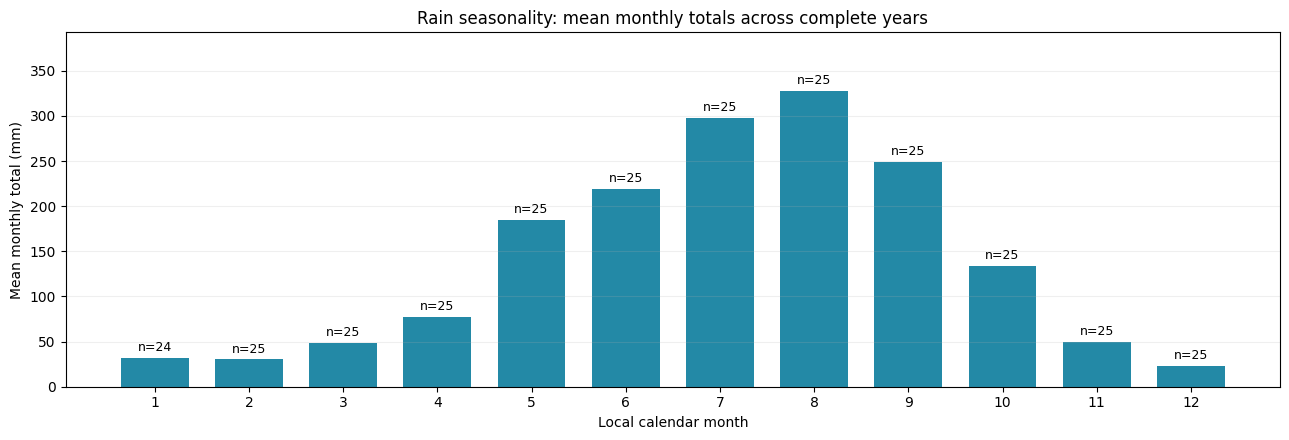

In [9]:
fig, ax = plt.subplots(figsize=(13,4.5))
ax.bar(month_order, rain_climatology.mean_mm, color='#2389a6', width=.72)
for m, row in rain_climatology.iterrows():
    if pd.notna(row.mean_mm):
        ax.annotate(f'n={int(row.n_years)}', (m,row.mean_mm),
                    xytext=(0,5), textcoords='offset points', ha='center', fontsize=9)
ax.set_xticks(month_order)
ax.set_xlabel('Local calendar month'); ax.set_ylabel('Mean monthly total (mm)')
ax.set_title('Rain seasonality: mean monthly totals across complete years')
ax.set_ylim(0, rain_climatology.mean_mm.max()*1.2)
ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

### 7.3. Boxplot tổng mưa theo 12 tháng
Mỗi nhóm chứa các tổng mưa của cùng một tháng qua nhiều năm. Đường giữa hộp là median; hộp trải từ Q1 đến Q3; râu dùng quy tắc 1,5×IQR. Hộp/râu rộng biểu thị tổng mưa biến động nhiều giữa các năm.

Các chấm ngoài râu là tổng mưa tháng khác biệt theo quy tắc thống kê, **không mặc định là lỗi và không bị xóa**. Biểu đồ chỉ mô tả lượng mưa: để khẳng định thời điểm bắt đầu/kết thúc mùa mưa cần tiêu chí riêng.

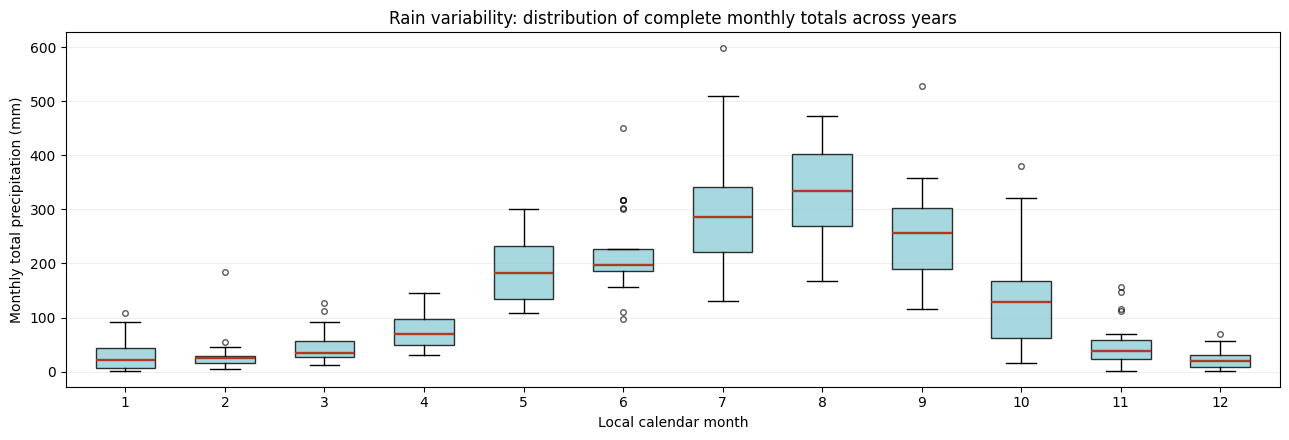

In [10]:
available_months = [m for m in month_order if rain_complete.month.eq(m).any()]
box_data = [rain_complete.loc[rain_complete.month.eq(m),'rain_total_mm'].to_numpy()
            for m in available_months]
fig, ax = plt.subplots(figsize=(13,4.5))
boxes = ax.boxplot(box_data, positions=available_months, widths=.6, patch_artist=True,
                  medianprops={'color':'#b03926','linewidth':1.7},
                  flierprops={'marker':'o','markersize':4,'alpha':.65})
for box in boxes['boxes']: box.set(facecolor='#91cdd8', alpha=.8)
ax.set_xticks(month_order); ax.set_xlim(.4,12.6)
ax.set_xlabel('Local calendar month'); ax.set_ylabel('Monthly total precipitation (mm)')
ax.set_title('Rain variability: distribution of complete monthly totals across years')
ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

### 7.4. Heatmap năm × tháng — giữ riêng từng năm
Mỗi ô = **tổng mưa của một tháng trong một năm**, không lấy trung bình nhiều năm. Cùng một thang màu được dùng cho toàn bảng để so các năm. Ô xám biểu thị tháng không đủ dữ liệu hoặc nằm ngoài phạm vi, **không phải mưa bằng 0**. Năm địa phương 2026 chỉ có 7 giờ nên không có tháng đầy đủ và không được vẽ thành một hàng trống.

Heatmap này khác heatmap **tháng × giờ** ở trên: heatmap tháng × giờ gộp dữ liệu nhiều năm để mô tả chu kỳ trung bình; heatmap năm × tháng cho thấy từng năm khác nhau như thế nào.

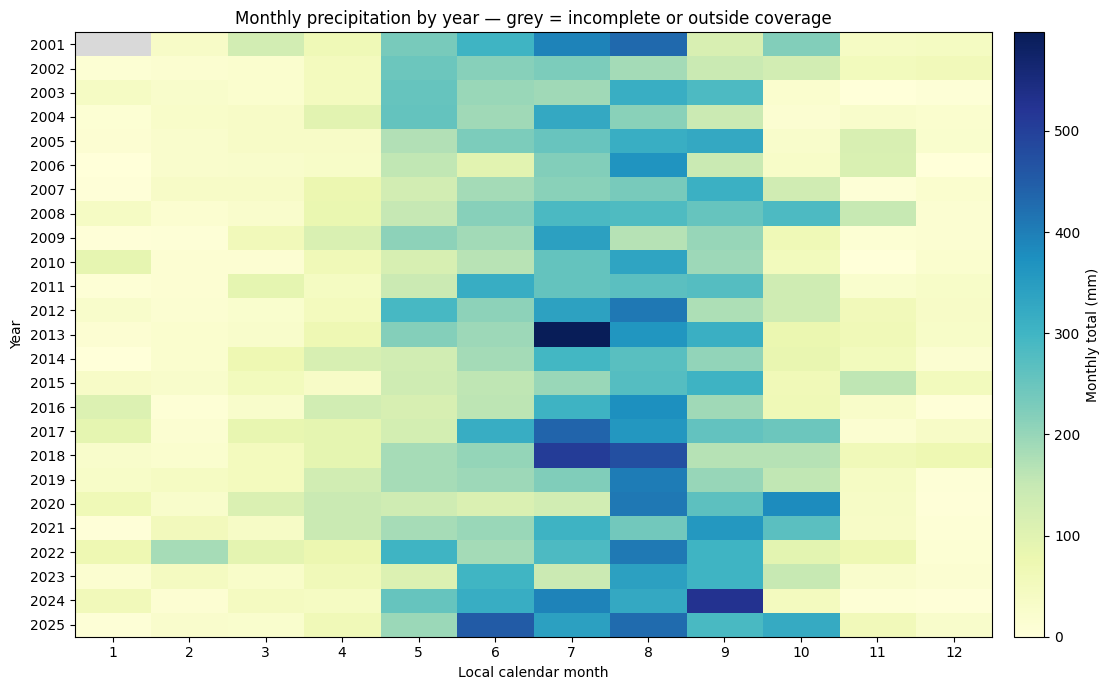

In [11]:
rain_year_month = rain_complete.pivot(index='year',columns='month',values='rain_total_mm')
rain_year_month = rain_year_month.reindex(columns=month_order).sort_index()
rain_cmap = plt.get_cmap('YlGnBu').copy()
rain_cmap.set_bad('#d9d9d9')
fig, ax = plt.subplots(figsize=(12, max(5, .28*len(rain_year_month))))
im = ax.imshow(np.ma.masked_invalid(rain_year_month.to_numpy()),
               aspect='auto', cmap=rain_cmap, vmin=0)
ax.set_xticks(np.arange(12), labels=range(1,13))
ax.set_yticks(np.arange(len(rain_year_month)), labels=rain_year_month.index)
ax.set_xlabel('Local calendar month'); ax.set_ylabel('Year')
ax.set_title('Monthly precipitation by year — grey = incomplete or outside coverage')
fig.colorbar(im, ax=ax, label='Monthly total (mm)', pad=.02)
ax.grid(False)
plt.tight_layout(); plt.show()
# Xuất bảng để kiểm tra các số dùng trong hình.
rain_monthly.to_csv(OUT/'rain_monthly_coverage.csv', encoding='utf-8-sig')
rain_climatology.to_csv(OUT/'rain_seasonality_12months.csv', encoding='utf-8-sig')
rain_year_month.to_csv(OUT/'rain_year_month_totals.csv', encoding='utf-8-sig')

**Cách đọc kết hợp:** dùng cột để xác định các tháng thường có tổng mưa cao/thấp; dùng boxplot để xem mức ổn định qua các năm; dùng heatmap để tìm năm/tháng khác biệt cần xem chi tiết. Ba hình bổ sung nhau và không tự chứng minh biến đổi khí hậu hay sai dữ liệu.

## 8. Sàng lọc ngoại lệ theo mùa–giờ, xử lý riêng mưa và hướng gió
Dùng IQR và modified Z-score (MAD) trong nhóm **cùng tháng, cùng giờ địa phương** qua 25 năm. Ví dụ tháng 1 lúc 12h gom các ngày của tháng 1 lúc 12h, không chỉ hai ngày giữa hai năm. Ngưỡng toàn kỳ phục vụ khám phá; MAD/IQR=0 thì không chia cho 0, bỏ phép kiểm tương ứng.

Mưa có nhiều số 0: dùng phân vị 99,5% trên **giờ có mưa >0,1** theo tháng để ưu tiên xem mưa lớn. WD2M chỉ kiểm miền/circular jump, không áp dụng Z-score/IQR tuyến tính. Điểm được gắn cờ vẫn giữ nguyên.


In [12]:
flags=[]
def add_flag(c, mask, reason, severity, score=None):
    mask=mask.reindex(clean.index).fillna(False)
    idx=clean.index[mask]
    if len(idx)==0: return
    scores = pd.Series(1.0,index=clean.index) if score is None else score.reindex(clean.index)
    flags.append(pd.DataFrame({'timestamp':idx,'variable':c,'value':clean.loc[idx,c].to_numpy(),
                              'reason':reason,'severity':severity,'score':scores.loc[idx].to_numpy()}))
keys=[clean.index.month,clean.index.hour]
threshold_tables=[]
for c in ['T2M','RH2M','PS','WS2M','ALLSKY_SFC_SW_DWN']:
    x=clean[c]; g=x.groupby(keys)
    q1=g.transform(lambda s:s.quantile(.25));q3=g.transform(lambda s:s.quantile(.75))
    iqr=q3-q1; median=g.transform('median')
    deviation=(x-median).abs(); mad=deviation.groupby(keys).transform('median')
    z=.6745*deviation/mad.replace(0,np.nan)
    iqr_flag=iqr.gt(0) & ((x<q1-1.5*iqr)|(x>q3+1.5*iqr))
    add_flag(c,iqr_flag,'seasonal_hour_IQR',1,deviation/iqr.replace(0,np.nan))
    add_flag(c,z.gt(3.5),'seasonal_hour_MAD',1,z)
    tab=g.agg(count='count',median='median',q1=lambda s:s.quantile(.25),q3=lambda s:s.quantile(.75))
    tab['MAD']=deviation.groupby(keys).median();tab['variable']=c
    threshold_tables.append(tab.rename_axis(['month','hour']).reset_index())
wet=clean.PRECTOTCORR.where(clean.PRECTOTCORR>RAIN_THRESHOLD)
wet_q=wet.groupby(clean.index.month).transform(lambda s:s.quantile(.995))
add_flag('PRECTOTCORR',wet.gt(wet_q),'wet_hour_month_q995',1,wet/wet_q.replace(0,np.nan))
thresholds=pd.concat(threshold_tables,ignore_index=True)
display(thresholds.head())
print('Các cờ này là ứng viên cần xem, chưa phải lỗi.')


Các cờ này là ứng viên cần xem, chưa phải lỗi.


,month,hour,count,median,q1,q3,MAD,variable
0,1,0,775,13.01,10.440,15.660,2.60,T2M
1,1,1,775,12.81,10.085,15.490,2.69,T2M
2,1,2,775,12.47,9.680,15.335,2.85,T2M
3,1,3,775,12.14,9.220,15.155,2.97,T2M
4,1,4,775,11.89,8.805,14.945,3.06,T2M


## 9. Bước nhảy, điểm nhọn, đoạn đứng yên và bức xạ đêm
Không missing vẫn có thể có bước nhảy hoặc đoạn hằng. Dùng chênh lệch 1 giờ, với hướng gió lấy cung ngắn nhất. Điểm nhọn có bước tăng rồi giảm ngược chiều lớn; kiểm này dùng t+1 để chẩn đoán hồi cứu, **không làm feature dự báo**.

Đoạn đứng yên ≥12 giờ chỉ sàng lọc T2M/RH2M/PS/WS2M/WD2M; mưa 0 và bức xạ 0 ban đêm được loại khỏi phép này. Hướng gió khi lặng gió hoặc RH=100 kéo dài cần ngữ cảnh, không tự kết luận lỗi.

Bức xạ trong 22h–03h >5 Wh/m² là cờ đêm bảo thủ; chưa dùng góc mặt trời tức thời để ép giá trị về 0. NASA cung cấp dữ liệu theo giờ, cần kiểm tra quy ước khoảng giờ trước khi sửa vùng bình minh/hoàng hôn.


In [13]:
for c in VARS:
    delta=clean[c].diff()
    if c=='WD2M': delta=(delta+180)%360-180
    jump=delta.abs();group=jump.groupby(keys)
    q=group.transform(lambda s:s.quantile(.995))
    floor={'T2M':4,'PRECTOTCORR':5,'RH2M':20,'PS':.5,'WS2M':3,'WD2M':150,'ALLSKY_SFC_SW_DWN':400}[c]
    large=jump.gt(q) & jump.gt(floor)
    add_flag(c,large,'large_hourly_jump',2,jump/np.maximum(q,floor))
    if c in ['T2M','PS','RH2M']:
        spike=large & large.shift(-1,fill_value=False) & delta.mul(delta.shift(-1)).lt(0)
        add_flag(c,spike,'isolated_reversing_spike',3,jump/np.maximum(q,floor))
flat_tables=[]
for c in ['T2M','RH2M','PS','WS2M','WD2M']:
    x=clean[c];run_id=(x.ne(x.shift())|x.isna()).cumsum()
    n=x.groupby(run_id).transform('size')
    flat=x.notna() & n.ge(12)
    add_flag(c,flat,'constant_run_ge12h',2,n/12)
    table=runs(flat);table['variable']=c;flat_tables.append(table)
flat_runs=pd.concat(flat_tables,ignore_index=True)
night=(clean.index.hour>=22)|(clean.index.hour<=3)
add_flag('ALLSKY_SFC_SW_DWN',pd.Series(night,index=clean.index)&clean.ALLSKY_SFC_SW_DWN.gt(5),
         'deep_night_radiation_gt5',3,clean.ALLSKY_SFC_SW_DWN/5)
# Sàng lọc bước đổi mức kéo dài: so median 7 ngày trước/sau trên residual mùa-giờ.
level_tables=[]
for c in ['T2M','PS','RH2M']:
    residual=clean[c]-clean[c].groupby(keys).transform('median')
    daily=residual.resample('D').median().where(residual.resample('D').count().ge(20))
    before=daily.shift(1).rolling(7,min_periods=7).median()
    after=daily.iloc[::-1].rolling(7,min_periods=7).median().iloc[::-1]
    shift=(after-before).abs()
    limit=max(float(shift.quantile(.995)),{'T2M':5,'PS':1,'RH2M':20}[c])
    rows=pd.DataFrame({'date':shift.index,'variable':c,'level_shift':shift.to_numpy(),'limit':limit})
    level_tables.append(rows.loc[rows.level_shift>limit])
level_candidates=pd.concat(level_tables,ignore_index=True)
flag_table=pd.concat(flags,ignore_index=True) if flags else pd.DataFrame(columns=['timestamp','variable','value','reason','severity','score'])
display(flag_table.groupby(['variable','reason']).size().rename('flagged_hours').to_frame())
display(level_candidates.head(20))


cell_27:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


flagged_hours
variable          reason                            
ALLSKY_SFC_SW_DWN large_hourly_jump               22
                  seasonal_hour_IQR              817
                  seasonal_hour_MAD              173
PRECTOTCORR       large_hourly_jump               21
                  wet_hour_month_q995            294
PS                seasonal_hour_IQR             1519
                  seasonal_hour_MAD              315
RH2M              constant_run_ge12h             108
                  large_hourly_jump               63
                  seasonal_hour_IQR             5974
                  seasonal_hour_MAD             5433
T2M               large_hourly_jump               42
                  seasonal_hour_IQR             2416
                  seasonal_hour_MAD              724
WD2M              large_hourly_jump              241
WS2M              large_hourly_jump                3
                  seasonal_hour_IQR             7688
                  seasonal_hour_MAD             6168

,date,variable,level_shift,limit
0,2002-11-29 00:00:00+07:00,T2M,10.5125,10.07
1,2002-11-30 00:00:00+07:00,T2M,10.9675,10.07
2,2002-12-01 00:00:00+07:00,T2M,11.4625,10.07
3,2002-12-02 00:00:00+07:00,T2M,10.9825,10.07
4,2002-12-08 00:00:00+07:00,T2M,10.2950,10.07
5,2002-12-23 00:00:00+07:00,T2M,10.0800,10.07
6,2003-03-04 00:00:00+07:00,T2M,10.4725,10.07
7,2009-02-28 00:00:00+07:00,T2M,10.2500,10.07
8,2009-03-01 00:00:00+07:00,T2M,10.6150,10.07
9,2009-03-02 00:00:00+07:00,T2M,10.6150,10.07


## 10. Gom sự kiện và ưu tiên kiểm tra
Gom các giờ liên tiếp theo biến, kết hợp nhiều lý do trên cùng điểm. Kiểm tra vài sự kiện điểm cao và lấy mẫu sự kiện mức thấp, thay vì đọc từng giờ bị IQR gắn cờ. Bảng đổi mức ở mục 9 là danh sách chẩn đoán riêng vì có đơn vị ngày.

Severity là độ ưu tiên điều tra: điểm nhọn/đêm 3, bước nhảy/đứng yên 2, thống kê 1. Điểm không phải xác suất lỗi. Cần đối chiếu JSON nguồn và bối cảnh trước quyết định.


In [14]:
events=[]
for c,part in flag_table.groupby('variable'):
    points=part.groupby('timestamp').agg(severity=('severity','max'), score=('score','max'),
                                       reasons=('reason',lambda x:'|'.join(sorted(set(x)))))
    points=points.sort_index()
    group=points.index.to_series().diff().ne(pd.Timedelta(hours=1)).cumsum()
    for _,block in points.groupby(group):
        events.append({'variable':c,'start':block.index[0],'end':block.index[-1],
                       'hours':len(block),'severity':int(block.severity.max()),
                       'score':float(block.score.max()),
                       'reasons':'|'.join(sorted(set('|'.join(block.reasons).split('|'))))})
events=pd.DataFrame(events,columns=['variable','start','end','hours','severity','score','reasons'])
events=events.sort_values(['severity','score'],ascending=False).reset_index(drop=True)
events['event_id']=['E%05d'%i for i in range(1,len(events)+1)]
display(events.head(20))
flagged_unique=flag_table[['timestamp','variable']].drop_duplicates()
print('Tổng sự kiện:',len(events),'| Ô được gắn cờ duy nhất:',len(flagged_unique),
      '| % trên mọi ô khí tượng:',round(100*len(flagged_unique)/(len(clean)*len(VARS)),3))
review=events.copy()
review['decision']='pending';review['evidence']='';review['reviewer']=''
# Các quyết định: keep_extreme / confirmed_error / unresolved. Không tự áp dụng bảng review.


Tổng sự kiện: 4399 | Ô được gắn cờ duy nhất: 20289 | % trên mọi ô khí tượng: 1.323


,variable,start,end,hours,severity,score,reasons,event_id
0,WS2M,2023-12-16 03:00:00+07:00,2023-12-16 08:00:00+07:00,6,2,12.733742,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00001
1,WS2M,2012-11-26 04:00:00+07:00,2012-11-26 07:00:00+07:00,4,2,10.443871,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00002
2,RH2M,2008-01-02 08:00:00+07:00,2008-01-03 03:00:00+07:00,20,2,7.439721,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00003
3,WS2M,2009-03-13 11:00:00+07:00,2009-03-13 15:00:00+07:00,5,2,5.430152,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00004
4,RH2M,2007-04-18 19:00:00+07:00,2007-04-19 10:00:00+07:00,16,2,5.341398,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00005
5,RH2M,2008-02-09 07:00:00+07:00,2008-02-09 11:00:00+07:00,5,2,5.206737,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00006
6,RH2M,2003-03-03 07:00:00+07:00,2003-03-03 20:00:00+07:00,14,2,4.690841,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00007
7,RH2M,2005-04-09 04:00:00+07:00,2005-04-09 20:00:00+07:00,17,2,4.660474,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00008
8,T2M,2003-05-06 09:00:00+07:00,2003-05-06 19:00:00+07:00,11,2,4.517250,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00009
9,RH2M,2008-02-10 07:00:00+07:00,2008-02-10 09:00:00+07:00,3,2,4.431566,large_hourly_jump|seasonal_hour_IQR|seasonal_hour_MAD,E00010


## 11. Vẽ tự động các ngữ cảnh cần xem
Dấu đỏ đánh dấu đúng điểm được gắn cờ. Vẽ ba sự kiện ưu tiên cao và ba sự kiện thống kê thuộc nhóm khác; tối đa 6 hình, không vẽ hàng nghìn tuần. Đọc cả các biến liên quan trong CSV khi cần: biến động nhiệt độ cùng RH/bức xạ có thể là thời tiết thật.

Đường gió có wrap-around; khi xem WD2M nên đọc số góc/chênh lệch circular thay vì coi đường nối 359→1 là bước nhảy lớn.


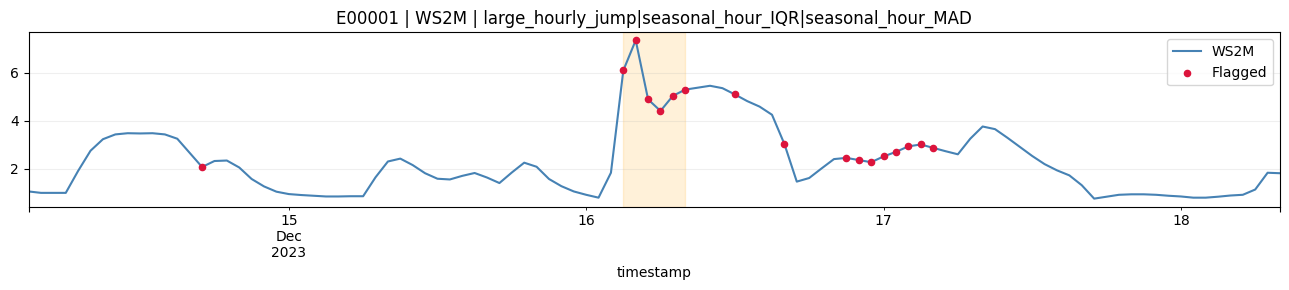

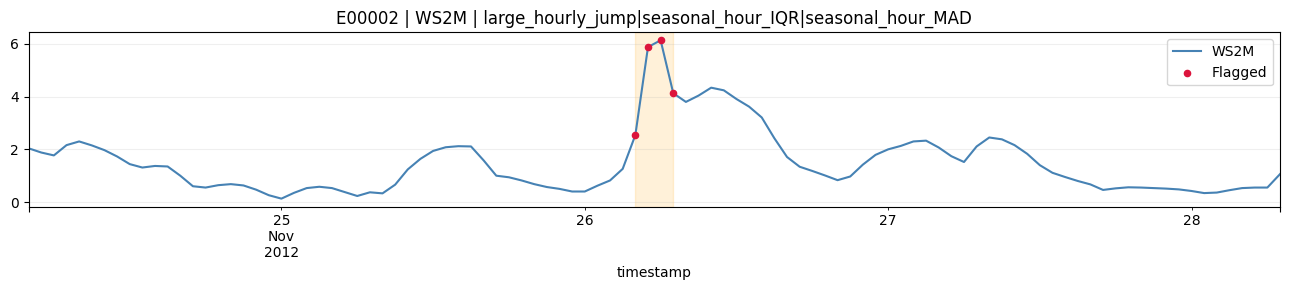

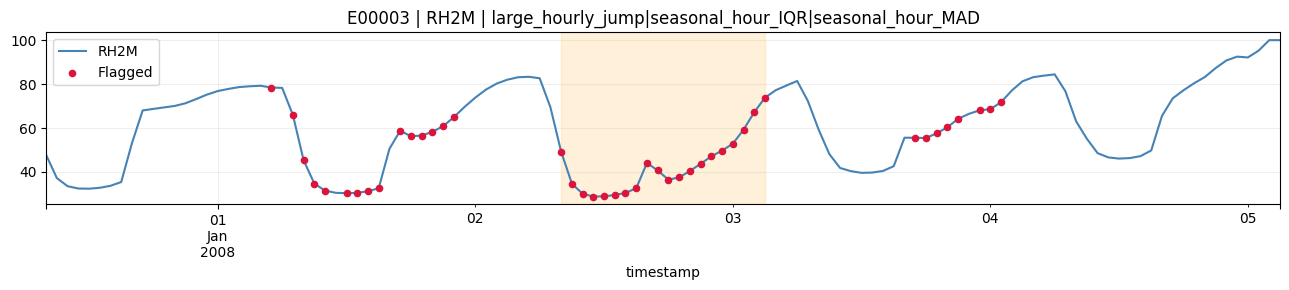

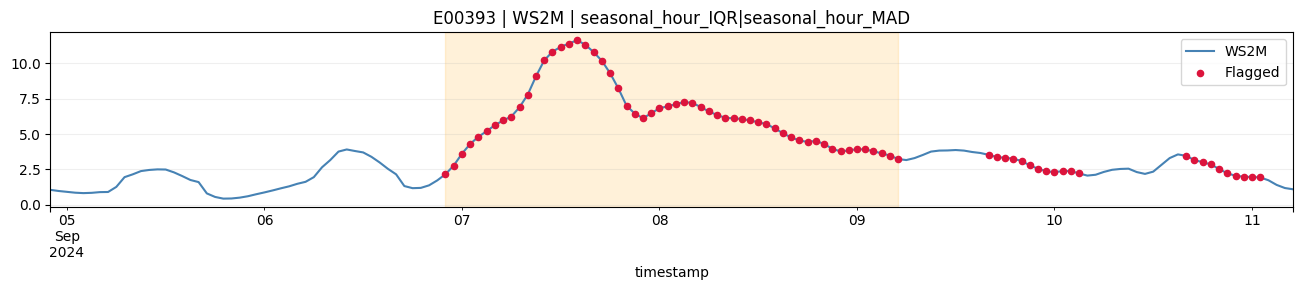

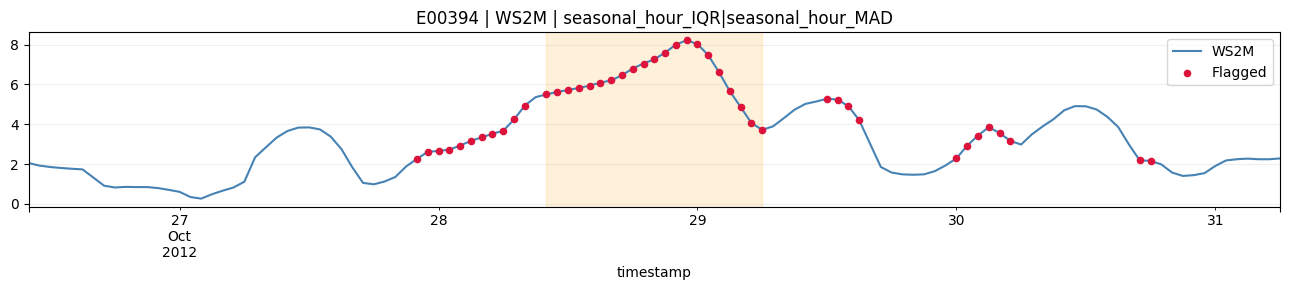

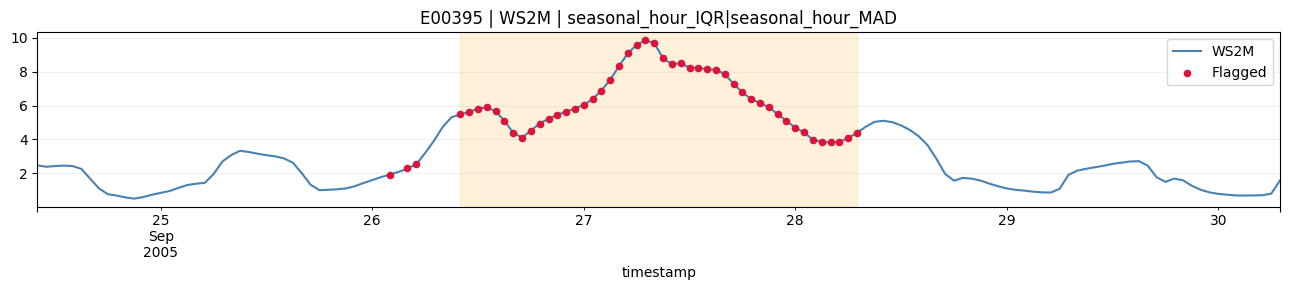

In [15]:
selected=pd.concat([events.head(3),events.loc[events.severity.eq(1)].head(3)]).drop_duplicates('event_id')
for _,e in selected.iterrows():
    c=e.variable;lo=e.start-pd.Timedelta(hours=48);hi=e.end+pd.Timedelta(hours=48)
    hi=min(hi,lo+pd.Timedelta(days=14))  # Giới hạn cửa sổ nếu sự kiện dài
    segment=clean.loc[lo:hi,c]
    ax=segment.plot(figsize=(13,3),color='steelblue')
    idx=pd.DatetimeIndex(flagged_unique.loc[flagged_unique.variable.eq(c),'timestamp'])
    idx=idx.intersection(segment.index)
    ax.scatter(idx,segment.reindex(idx),color='crimson',s=20,label='Flagged',zorder=3)
    ax.axvspan(e.start,min(e.end,hi),color='orange',alpha=.15)
    ax.set_title(f'{e.event_id} | {c} | {e.reasons}');ax.legend()
    plt.tight_layout();plt.show()


## 12. Kết luận động và quy tắc xử lý cho dự án
Các kết luận được tính từ dữ liệu thật sau Run All. Số cờ lớn không buộc kiểm tra từng điểm: gom theo sự kiện, xem nhóm nhiều tín hiệu, so nguồn và lưu quyết định. Không dùng smoothing cho nhiệt độ/mưa chỉ để đồ thị đẹp; có thể làm mất tín hiệu dự báo.

| Loại vấn đề | Hành động |
|---|---|
| Lỗi parse, fill value, miền vật lý | Đổi thành thiếu, log từng ô |
| Trùng giống nhau | Gộp; giữ source_row_numbers |
| Trùng xung đột/timezone chưa rõ | Chặn, xác minh nguồn |
| Thiếu giờ | Bổ sung trục giờ, cờ is_inserted_hour |
| Thiếu biến | Giữ NaN mặc định; chỉ tùy chọn điền ngắn nhân quả cho T/RH/PS |
| Outlier theo mùa, mưa cực đoan | Giữ giá trị, gắn cờ, kiểm tra sự kiện |
| Điểm nhọn/đứng yên/đổi mức | Kiểm tra ngữ cảnh và JSON; chỉ sửa khi có bằng chứng |
| WD2M | Chuẩn hóa 360→0; circular difference, không IQR tuyến tính |

Dữ liệu này cho phép nghiên cứu dự báo T2M và PRECTOTCORR tại t+1 giờ; rain_flag theo ngưỡng >0,1 mm/giờ. Khi sang mô hình: tạo lag/rolling đến t, nhãn đúng t+1, chia thời gian và chỉ fit các biến đổi trên train; không dùng target imputed để chấm điểm. Bản cleaned có NaN chưa phải đầu vào trực tiếp cho features.py hiện tại.


In [16]:
summary = {'source_zip':'Weather-Prediction-ML(2).zip','raw_sha256':raw_hash,
           **time_audit,'invalid_cells':invalid_counts,
           'imputed_rows':int(clean.is_imputed.sum()),
           'remaining_missing_cells':int(clean[VARS].isna().sum().sum()),
           'unique_flagged_cells':len(flagged_unique),'events':len(events),
           'level_shift_candidates':len(level_candidates),'automatic_statistical_deletions':0}
display(Markdown(f"""**Kết quả trên bản mới:** {len(raw):,} dòng nguồn / {len(expected):,} giờ kỳ vọng;
{len(missing_hours)} giờ thiếu, {int(ts.duplicated().sum())} timestamp trùng;
{sum(invalid_counts.values())} ô không hợp lệ; {summary['remaining_missing_cells']} ô còn thiếu.
{len(flagged_unique):,} ô có cờ, gom thành {len(events):,} sự kiện.
**Giữ nguyên mọi ngoại lệ thống kê**; bảng review là bước xác minh tiếp theo."""))


**Kết quả trên bản mới:** 219,144 dòng nguồn / 219,144 giờ kỳ vọng;
0 giờ thiếu, 0 timestamp trùng;
0 ô không hợp lệ; 0 ô còn thiếu.
20,289 ô có cờ, gom thành 4,399 sự kiện.
**Giữ nguyên mọi ngoại lệ thống kê**; bảng review là bước xác minh tiếp theo.

## 13. Xuất cleaned riêng, metadata/hash và các bảng kiểm tra
File sạch nằm trong `outputs/timeseries_quality_v2/`, có record_id cùng quy ước dự án và cờ provenance. Quality flags tách riêng để không vô tình đưa chẩn đoán dùng tương lai vào features. Bảng review chỉ tạo nếu chưa tồn tại để Run All không xóa ghi chú người kiểm tra.

Mỗi lần chạy sẽ cập nhật các báo cáo còn lại trong thư mục này. Dữ liệu raw, cleaned gốc, processed và src không bị sửa.


In [17]:
from uuid import uuid5, NAMESPACE_URL
station='NASA_POWER_HANOI_21.0285_105.8542'
export=clean.copy()
export['station_id']=station
export['record_id']=[str(uuid5(NAMESPACE_URL, f"nasa-power/hourly/{station}/{t.tz_convert('UTC').strftime('%Y-%m-%dT%H:00:00Z')}")) for t in export.index]
assert export.index.is_unique and export.index.is_monotonic_increasing
assert export.index.equals(expected)
assert export.record_id.is_unique
assert sha(RAW_PATH)==raw_hash, 'Nguồn raw đã thay đổi trong khi chạy.'
clean_out=OUT/(STEM+'_quality_clean.csv')
export.reset_index().to_csv(clean_out,index=False,encoding='utf-8-sig')
for name,table in {'raw_audit':audit(raw),'hidden_missing':hidden,'missing_runs':gaps,
                   'flat_runs':flat_runs,'seasonal_thresholds':thresholds,'quality_flags':flag_table,
                   'events':events,'level_shift_candidates':level_candidates,
                   'existing_cleaned_comparison':existing_comparison}.items():
    table.to_csv(OUT/(name+'.csv'),index=name in ['raw_audit','hidden_missing','existing_cleaned_comparison'],encoding='utf-8-sig')
pd.DataFrame(change_log,columns=['source_row','timestamp','column','before','after','reason']).to_csv(OUT/'change_log.csv',index=False,encoding='utf-8-sig')
review_path=OUT/'review_decisions.csv'
if not review_path.exists(): review.to_csv(review_path,index=False,encoding='utf-8-sig')
metadata={**summary,'generated_at':datetime.now(timezone.utc).isoformat(),
          'cleaned_sha256':sha(clean_out),'timezone':'UTC+07:00',
          'parameters':raw_meta['parameters'], 'fill_short_gaps':FILL_SHORT_GAPS,
          'max_fill_hours':MAX_FILL_HOURS, 'pandas':pd.__version__,'numpy':np.__version__,
          'python':platform.python_version(),
          'policy':'Keep statistical extremes; retain unresolved NaN; optional past-only ffill T2M/RH2M/PS <=2h.',
          'eda_only':'Seasonal thresholds and retrospective diagnostics use the whole dataset; refit on train for modeling.'}
clean_out.with_suffix('.metadata.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding='utf-8')
print('Đã xuất:',OUT)
print('CSV sạch:',clean_out.name)
print('Bảng cần xem:', 'events.csv, level_shift_candidates.csv, review_decisions.csv')


Đã xuất: /workspace/scratch/b522d59c3fb8/project/Weather-Prediction-ML/outputs/timeseries_quality_v2
CSV sạch: hanoi_hourly_20010101_20251231_quality_clean.csv
Bảng cần xem: events.csv, level_shift_candidates.csv, review_decisions.csv
